In [1]:
import sys

from pathlib import Path
import h5py
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from lab_tools.io import read_keysight_h5

In [2]:
def print_info(time, voltage, metadata):
    print("frame:        ", metadata["frame"])
    print("time shape:   ", time.shape)
    print("voltage shape:", voltage.shape)
    print("X units:      ", metadata["channel_attrs"]["XUnits"]) # time units
    print("Y units:      ", metadata["channel_attrs"]["YUnits"]) # voltage units 
    print("XInc:         ", metadata["channel_attrs"]["XInc"])   # time step between samples
    print("YInc:         ", metadata["channel_attrs"]["YInc"])   # voltage step between ADC samples

def standard_units(time, voltage, metadata):
    voltage_mV = voltage * 1e3
    adc_step_mV = metadata["channel_attrs"]["YInc"] * 1e3  
    time_us = time * 1e6
    units_V = "mV"
    units_time = "µs"
    return time_us, voltage_mV, adc_step_mV, units_time, units_V



In [3]:
folder = "Basis"
# H: Hamamatsu basis 
# Indexes
    # 1:  50 us
    # 2: 100 us
    # 3:   1 us
    # 4:   0.2 us


Data file: Basis/basisH-2.h5
frame:         {'Model': 'EXR054A', 'Serial': 'MY63310243', 'Date': '20-May-2026  8:10:02'}
time shape:    (1600001,)
voltage shape: (1, 1600001)
X units:       Second
Y units:       Volt
XInc:          6.25e-11
YInc:          2.1383186705767352e-07
Data file: Basis/basisUs-2.h5
frame:         {'Model': 'EXR054A', 'Serial': 'MY63310243', 'Date': '20-May-2026  9:30:24'}
time shape:    (1600001,)
voltage shape: (1, 1600001)
X units:       Second
Y units:       Volt
XInc:          6.25e-11
YInc:          2.1383186705767352e-07


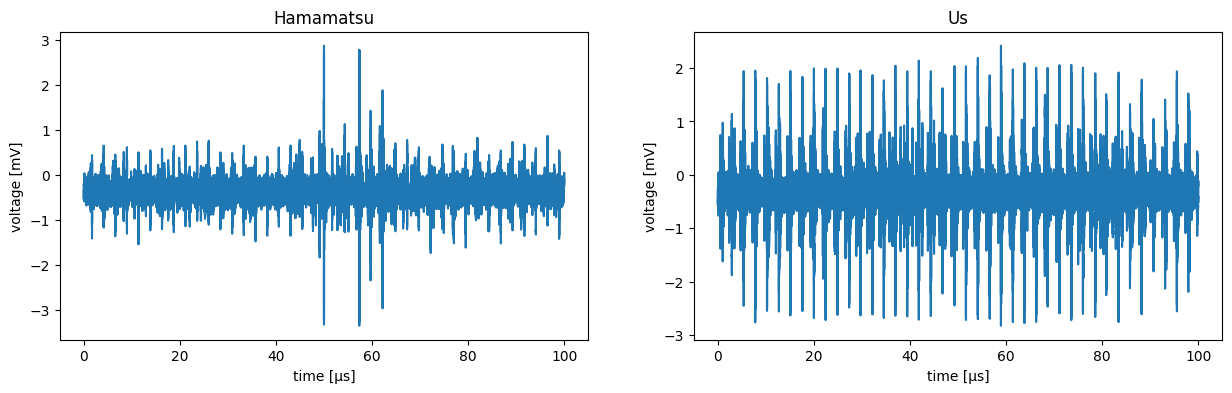

In [4]:
idx=2
data_file = f"{folder}/basisH-{idx}.h5"
timeH, voltageH, metadataH = read_keysight_h5( data_file, segment_numbers=None)
print("Data file:", data_file)
print_info(timeH, voltageH, metadataH)
timeH_us, voltageH_mV, adcStepH_mV, units_time, units_V = standard_units(timeH, voltageH, metadataH)

data_file = f"{folder}/basisUs-{idx}.h5"
time, voltage, metadata = read_keysight_h5( data_file, segment_numbers=None)
print("Data file:", data_file)
print_info(time, voltage, metadata)
time_us, voltage_mV, adcStep_mV, units_time, units_V = standard_units(time, voltage, metadata)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(timeH_us, voltageH_mV[0])
axs[0].set_xlabel(f"time [{units_time}]")
axs[0].set_ylabel(f"voltage [{units_V}]")
axs[0].set_title("Hamamatsu")

axs[1].plot(time_us, voltage_mV[0])
axs[1].set_xlabel(f"time [{units_time}]")
axs[1].set_ylabel(f"voltage [{units_V}]")
axs[1].set_title("Us")
plt.show();

# Noise

In [5]:
def guassian_fit_to_histV(t, v, adc_step, units_V):
    voltage = v
    # --------------------------------------------------
    # Build histogram
    # --------------------------------------------------

    # Use a bin width several ADC codes wide
    bin_width = 5 * adc_step
    bin_edges = np.arange(
        np.min(voltage),
        np.max(voltage) + bin_width,
        bin_width
    )
    counts, bin_edges = np.histogram(
        voltage,
        bins=bin_edges
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    print(f"ADC step  = {adc_step:.3e} {units_V}")
    print(f"Bin width = {bin_width:.3e} {units_V}")
    print(f"Number of bins = {len(bin_edges)-1}")

    # --------------------------------------------------
    # Gaussian fit function
    # --------------------------------------------------

    def gaussian(x, A, mu, sigma):
        return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # --------------------------------------------------
    # Initial values
    # --------------------------------------------------

    A0 = np.max(counts)
    mu0 = np.mean(voltage)
    sigma0 = np.std(voltage)

    p0 = [A0, mu0, sigma0]

    # --------------------------------------------------
    # Fit
    # --------------------------------------------------

    # Ignore empty bins (for stability)
    fit_mask = counts > 0

    popt, pcov = curve_fit(
        gaussian,
        bin_centers,
        counts,
        p0=p0
    )

    A_fit, mu_fit, sigma_fit = popt

    # --------------------------------------------------
    # Output
    # --------------------------------------------------

    threshold_pos = mu_fit + 5 * sigma_fit
    threshold_neg = mu_fit - 5 * sigma_fit

    print(f"Baseline mean     = {mu_fit:.3f} {units_V}")
    print(f"Baseline sigma    = {sigma_fit:.3f} {units_V}")
    print(f"+5 sigma threshold = {threshold_pos:.3f} {units_V}")
    print(f"-5 sigma threshold = {threshold_neg:.3f} {units_V}")

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    xfit = np.linspace(bin_edges[0], bin_edges[-1], 2000)
    yfit = gaussian(xfit, *popt)

    plt.figure(figsize=(8,5))

    # Plot histogram used in fit

    plt.bar(
        bin_centers,
        counts,
        width=bin_width,
        alpha=0.6,
        align='center',
        label='Baseline histogram'

    )
    plt.plot(xfit, yfit, linewidth=1.5, label='Gaussian fit')
    
    plt.axvline(threshold_pos, linestyle='--', label='+5σ threshold')
    plt.axvline(threshold_neg, linestyle='--', label='-5σ threshold')
    plt.xlabel(f"Voltage [{units_V}]")
    plt.ylabel("Counts")
    plt.legend()
    plt.tight_layout()
    plt.show()
    


ADC step  = 2.138e-04 mV
Bin width = 1.069e-03 mV
Number of bins = 5835
Baseline mean     = -0.363 mV
Baseline sigma    = 0.155 mV
+5 sigma threshold = 0.414 mV
-5 sigma threshold = -1.140 mV


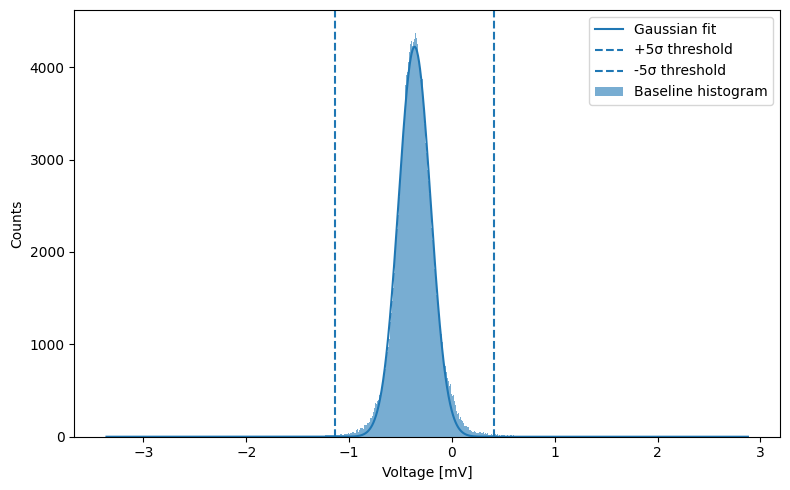

In [6]:
guassian_fit_to_histV(t=timeH_us, v=voltageH_mV, adc_step=adcStepH_mV, units_V=units_V)

ADC step  = 2.138e-04 mV
Bin width = 1.069e-03 mV
Number of bins = 4903
Baseline mean     = -0.319 mV
Baseline sigma    = 0.134 mV
+5 sigma threshold = 0.354 mV
-5 sigma threshold = -0.991 mV


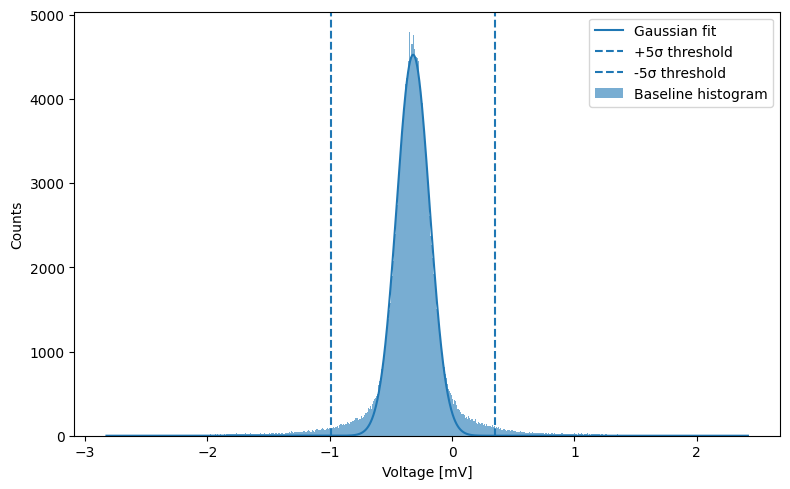

In [7]:
guassian_fit_to_histV(t=time_us, v=voltage_mV, adc_step=adcStep_mV, units_V=units_V)

# Spectral Analysis

In [110]:
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

def get_basic_variables(t, V):
    N = len(V)
    dt = np.mean(np.diff(t))
    fs = 1/dt
    # remove DC offset
    V0 = V - np.mean(V)
    return N, dt, fs, V0
    

def fft_plot(t, V, hannW = True, find_peaks_fact=0.05, find_peaks_dist=1000, Nfreq_list=10, verbose=False):
    """
    t: time array [s]
    V: voltage array [V]
    hannW: to use or not to use a Hann window
    find_peaks_prom_fact: prominence factor (used in find_peaks)
    find_peaks_dist: distance between peaks (used in find_peaks)
    Nfreq_list: how many most important frequencies
    """
    N, dt, _, V0 = get_basic_variables(t, V)

    # N = len(V)
    # dt = np.mean(np.diff(t))

    # # remove DC offset
    # V0 = V - np.mean(V)

    # Hann window
    # smoothly forces the signal to 0 at the edges of the window (fft assumes that the signal is repeated forever - so that the end of the window is the begining of the signal)
    window = np.hanning(N) if hannW else 1

    # FFT
    Y = fft(V0 * window)

    # frequencies
    f = fftfreq(N, dt)

    # positive frequencies only
    mask = f > 0
    fpos = f[mask]
    A = 2/N * np.abs(Y[mask])

    peaks, properties = find_peaks(
        A,
        # prominence=np.max(A)*find_peaks_fact, # tune it
        height=np.max(A)*find_peaks_fact, # tune it
        distance=find_peaks_dist # tune it
    )
        
    # sort peaks by amplitude
    sorted_idx = np.argsort(A[peaks])[::-1]
    # keep only strongest peaks
    top_peaks = peaks[sorted_idx[:Nfreq_list]]

    plt.figure(figsize=(12,6))
    plt.plot(fpos/1e6, A, label='FFT')
    # mark peaks
    plt.plot(
        fpos[top_peaks]/1e6,
        A[top_peaks],
        'rx',
        markersize=10,
        label='Detected peaks'
    )
    if verbose:
        print("\nDominant frequencies:")
        for p in top_peaks:
            print(f"{fpos[p]/1e6:.3f} MHz")

    # annotate frequencies
    for p in top_peaks:
        freq_mhz = fpos[p] / 1e6
        amp = A[p]
        plt.annotate(
            f'{freq_mhz:.2f} MHz',
            xy=(freq_mhz, amp),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            rotation=45
        )

    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Amplitude")
    plt.xscale("log")     
    # plt.xlim(0.1, 100)  # optional zoom
    plt.grid()
    plt.legend()
    plt.show()
    
    return fpos, A
    

In [111]:
# t = timeH
# V = voltageH[0]

t = time
V = voltage[0]

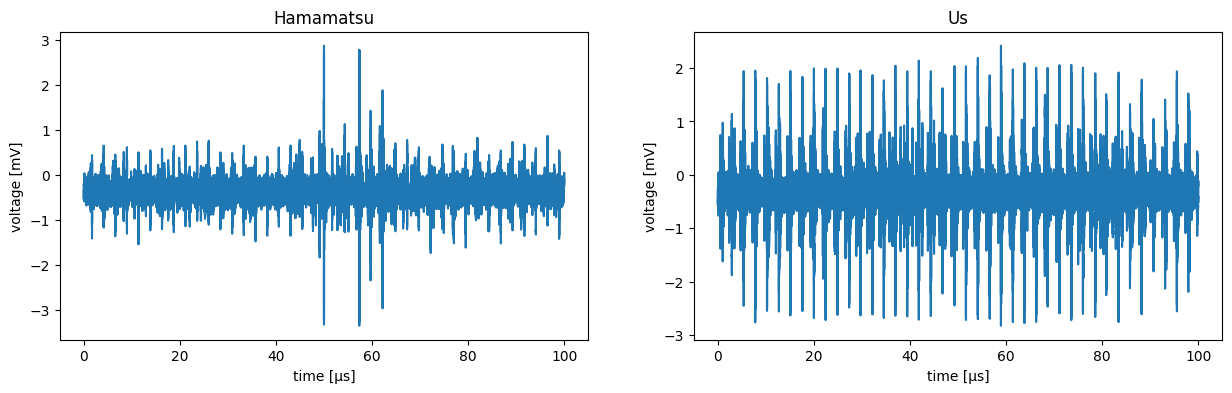

In [112]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(timeH_us, voltageH_mV[0])
axs[0].set_xlabel(f"time [{units_time}]")
axs[0].set_ylabel(f"voltage [{units_V}]")
axs[0].set_title("Hamamatsu")

axs[1].plot(time_us, voltage_mV[0])
axs[1].set_xlabel(f"time [{units_time}]")
axs[1].set_ylabel(f"voltage [{units_V}]")
axs[1].set_title("Us")
plt.show();


Dominant frequencies:
205.380 MHz
77.130 MHz
192.480 MHz
90.990 MHz
24.070 MHz
215.600 MHz
1.280 MHz
176.370 MHz
102.990 MHz
225.990 MHz


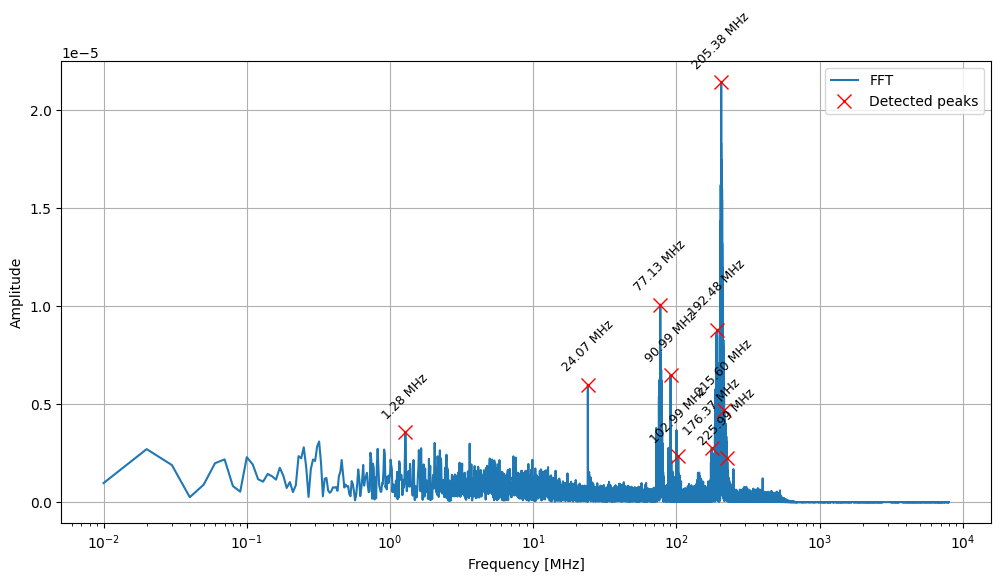

In [113]:
fpos, A = fft_plot(t, V, hannW = True, find_peaks_fact=0.1, find_peaks_dist=1000, Nfreq_list=10, verbose=True)

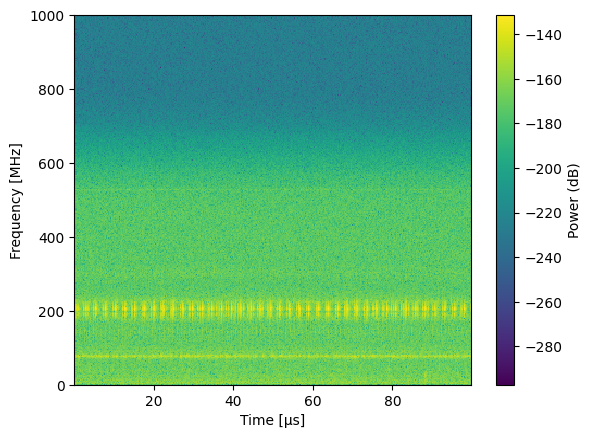

In [ ]:
from scipy.signal import spectrogram

N, dt, fs, V0 = get_basic_variables(t, V)

freqs, times, Sxx = spectrogram(
    V0,
    fs=fs,
    nperseg=5000 #1024
)
# 10*np.log10(Sxx + 1e-30),
plt.pcolormesh(times*1e6, freqs/1e6, 10*np.log10(Sxx))
plt.ylabel("Frequency [MHz]")
plt.xlabel("Time [µs]")
plt.colorbar(label="Power (dB)")
# plt.ylim(0, 1.6e3)   # MHz
plt.ylim(0, 1.e3)   # MHz
plt.show()